In [17]:
import polars as pl

# load the data
df = pl.scan_csv("../data/EURUSD_1s_2024.csv")

In [18]:
# Convert the timestamp column to datetime format
df = (
    pl.scan_csv("../data/EURUSD_1s_2024.csv")
    .with_columns(
        pl.col("timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S%z")
    )
)


In [19]:
df.head(10).collect()

timestamp,bid_open,bid_high,bid_low,bid_close,bid_volume,ask_open,ask_high,ask_low,ask_close,ask_volume
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-01-01 22:00:12 UTC,1.10427,1.10427,1.10427,1.10427,0.9,1.10481,1.10481,1.10481,1.10481,0.9
2024-01-01 22:00:14 UTC,1.10425,1.10425,1.10425,1.10425,0.9,1.1048,1.1048,1.1048,1.1048,0.9
2024-01-01 22:00:18 UTC,1.10425,1.10425,1.10425,1.10425,0.9,1.10476,1.10476,1.10476,1.10476,0.5
2024-01-01 22:00:25 UTC,1.10425,1.10425,1.10425,1.10425,0.9,1.1048,1.1048,1.1048,1.1048,0.9
2024-01-01 22:00:36 UTC,1.10429,1.10429,1.10429,1.10429,0.5,1.1048,1.1048,1.1048,1.1048,0.9
2024-01-01 22:00:44 UTC,1.10425,1.10425,1.10425,1.10425,0.9,1.1048,1.1048,1.1048,1.1048,0.9
2024-01-01 22:00:54 UTC,1.10429,1.10429,1.10429,1.10429,0.9,1.1048,1.1048,1.1048,1.1048,0.9
2024-01-01 22:01:04 UTC,1.10429,1.10429,1.10429,1.10429,0.9,1.10477,1.10477,1.10477,1.10477,0.9
2024-01-01 22:01:08 UTC,1.10429,1.10429,1.10429,1.10429,1.8,1.10478,1.10478,1.10477,1.10477,6.3


In [22]:
#  checking for duplicates in the timestamp column
dupes = (
    df.group_by("timestamp")
      .agg(pl.len().alias("n"))
      .filter(pl.col("n") > 1)
      .sort("n", descending=True)
      .collect()
)

print(f"{dupes.height} timestamps with duplicates, {dupes['n'].sum()} rows total")
dupes.head(20)

0 timestamps with duplicates, 0 rows total


timestamp,n
"datetime[μs, UTC]",u32


In [21]:
# there was a bug with how the month to month data that caused rows to be duplicated. We will remove the duplicates and keep the first row for each timestamp.
df = df.unique(subset=["timestamp"], keep="first", maintain_order=True)

In [ ]:
## Check for null values in the dataframe
df.null_count().collect()

timestamp,bid_open,bid_high,bid_low,bid_close,bid_volume,ask_open,ask_high,ask_low,ask_close,ask_volume
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Check for NaN values in the dataframe
df.select(pl.col(pl.Float64).is_nan().sum()).collect()

bid_open,bid_high,bid_low,bid_close,bid_volume,ask_open,ask_high,ask_low,ask_close,ask_volume
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0


In [25]:
# Checking the consistency of OHLC values
def ohlc_violations(side: str):
    o, h, l, c = (pl.col(f"{side}_{x}") for x in ("open", "high", "low", "close"))
    return (
        (h < pl.max_horizontal(o, c, l)).alias(f"{side}_high_bad")
        | (l > pl.min_horizontal(o, c, h)).alias(f"{side}_low_bad")
    )

checked = df.with_columns(
    bid_bad = ohlc_violations("bid"),
    ask_bad = ohlc_violations("ask"),
)

# counts
checked.select(
    bid_bad = pl.col("bid_bad").sum(),
    ask_bad = pl.col("ask_bad").sum(),
).collect()


bid_bad,ask_bad
u32,u32
0,0


In [26]:
# check spread is always positive
spread = df.with_columns(
    bad_open  = pl.col("ask_open")  < pl.col("bid_open"),
    bad_high  = pl.col("ask_high")  < pl.col("bid_high"),
    bad_low   = pl.col("ask_low")   < pl.col("bid_low"),
    bad_close = pl.col("ask_close") < pl.col("bid_close"),
)

spread.select(
    bad_open  = pl.col("bad_open").sum(),
    bad_high  = pl.col("bad_high").sum(),
    bad_low   = pl.col("bad_low").sum(),
    bad_close = pl.col("bad_close").sum(),
).collect()


bad_open,bad_high,bad_low,bad_close
u32,u32,u32,u32
0,0,0,0


In [27]:
from datetime import date

def analyze_gaps(lf: pl.LazyFrame, ts_col="timestamp", report_threshold_s=600):
    """Gap analysis for irregular tick/bar data. Returns (summary, gaps)."""
    HOLIDAYS = {  # UTC dates where a multi-hour weekday gap is expected
        date(2024, 1, 1), date(2024, 3, 29), date(2024, 12, 24),
        date(2024, 12, 25), date(2024, 12, 26), date(2024, 12, 31),
    }

    g = (
        lf.sort(ts_col)
          .select(start=pl.col(ts_col).shift(1), end=pl.col(ts_col))
          .drop_nulls()
          .with_columns(
              gap_s=(pl.col("end") - pl.col("start")).dt.total_seconds(),
              start_dow=pl.col("start").dt.weekday(),          # Mon=1 .. Sun=7
          )
          .collect()
    )

    is_weekend = (pl.col("start_dow") == 5) & pl.col("end").dt.weekday().is_in([6, 7])
    is_holiday = (
        pl.col("start").dt.date().is_in(list(HOLIDAYS))
        | pl.col("end").dt.date().is_in(list(HOLIDAYS))
    )

    g = g.with_columns(
        kind=pl.when(is_weekend).then(pl.lit("weekend"))
              .when(is_holiday).then(pl.lit("holiday"))
              .otherwise(pl.lit("unexplained"))
    )

    gaps = (
        g.filter((pl.col("gap_s") >= report_threshold_s) | (pl.col("kind") == "weekend"))
         .with_columns(gap_h=(pl.col("gap_s") / 3600).round(2))
         .select("start", "end", "gap_s", "gap_h", "kind", "start_dow")
         .sort("gap_s", descending=True)
    )

    summary = pl.DataFrame({
        "n_bars":             [g.height + 1],
        "span_start":         [g["start"].min()],
        "span_end":           [g["end"].max()],
        "median_gap_s":       [g["gap_s"].median()],
        "p99_gap_s":          [g["gap_s"].quantile(0.99)],
        "p999_gap_s":         [g["gap_s"].quantile(0.999)],
        "max_intraday_gap_s": [g.filter(pl.col("kind") == "unexplained")["gap_s"].max()],
        "n_weekend_gaps":     [(g["kind"] == "weekend").sum()],
        "n_holiday_gaps":     [g.filter((pl.col("kind") == "holiday") & (pl.col("gap_s") >= report_threshold_s)).height],
        "n_unexplained":      [g.filter((pl.col("kind") == "unexplained") & (pl.col("gap_s") >= report_threshold_s)).height],
    })
    return summary, gaps


In [28]:
summary, gaps = analyze_gaps(df)

with pl.Config(tbl_cols=-1, tbl_width_chars=250):
    display(summary)
    display(gaps.filter(pl.col("kind") != "weekend"))   # the interesting ones

print("weekend gaps:", gaps.filter(pl.col("kind") == "weekend").height,
      "| hours:", gaps.filter(pl.col("kind") == "weekend")["gap_h"].min(),
      "-", gaps.filter(pl.col("kind") == "weekend")["gap_h"].max())


n_bars,span_start,span_end,median_gap_s,p99_gap_s,p999_gap_s,max_intraday_gap_s,n_weekend_gaps,n_holiday_gaps,n_unexplained
i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,i64,i64,i64,i64
8841601,2024-01-01 22:00:12 UTC,2024-12-31 21:59:58 UTC,1.0,19.0,50.0,561,52,8,0


start,end,gap_s,gap_h,kind,start_dow
"datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,str,i8
2024-12-25 07:59:59 UTC,2024-12-25 22:04:01 UTC,50642,14.07,"""holiday""",3
2024-12-25 02:14:49 UTC,2024-12-25 02:33:11 UTC,1102,0.31,"""holiday""",3
2024-12-25 04:43:44 UTC,2024-12-25 05:00:14 UTC,990,0.28,"""holiday""",3
2024-12-25 03:11:50 UTC,2024-12-25 03:28:12 UTC,982,0.27,"""holiday""",3
2024-12-24 23:15:03 UTC,2024-12-24 23:29:39 UTC,876,0.24,"""holiday""",2
2024-12-24 23:33:57 UTC,2024-12-24 23:47:29 UTC,812,0.23,"""holiday""",2
2024-12-25 01:48:17 UTC,2024-12-25 02:01:37 UTC,800,0.22,"""holiday""",3
2024-12-24 22:43:27 UTC,2024-12-24 22:54:42 UTC,675,0.19,"""holiday""",2


weekend gaps: 52 | hours: 47.0 - 49.0


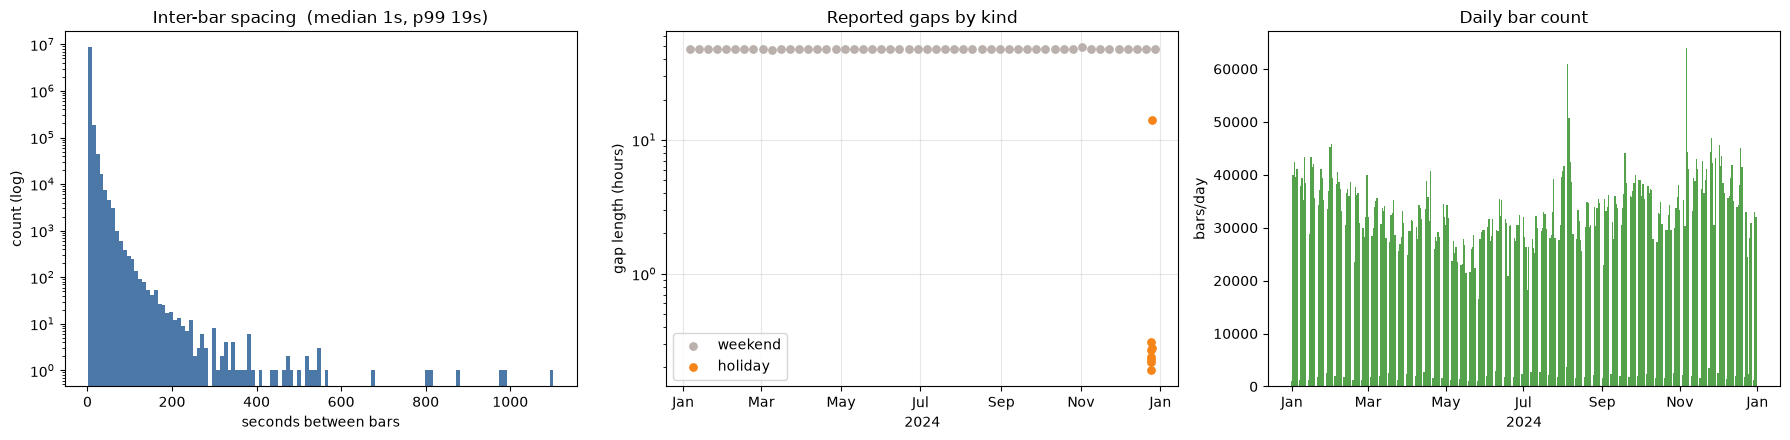

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# full inter-bar spacing (for the distribution panel)
all_gaps = (
    df.sort("timestamp")
      .select(gap_s=pl.col("timestamp").diff().dt.total_seconds())
      .drop_nulls()
      .collect()["gap_s"]
)

daily = (
    df.group_by(pl.col("timestamp").dt.date().alias("d"))
      .agg(n=pl.len()).sort("d").collect()
)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# 1: normal spacing regime (< 1h)
ax[0].hist(all_gaps.filter(all_gaps < 3600), bins=120, log=True, color="#4C78A8")
ax[0].set(xlabel="seconds between bars", ylabel="count (log)",
          title=f"Inter-bar spacing  (median {all_gaps.median():.0f}s, "
                f"p99 {all_gaps.quantile(0.99):.0f}s)")

# 2: every reported gap, placed in the year, coloured by kind
colors = {"weekend": "#BAB0AC", "holiday": "#F58518", "unexplained": "#E45756"}
for k, c in colors.items():
    sub = gaps.filter(pl.col("kind") == k)
    if sub.height:
        ax[1].scatter(sub["start"].to_list(), sub["gap_h"], s=28, label=k,
                      color=c, zorder=1 if k == "weekend" else 3)
ax[1].set(yscale="log", xlabel="2024", ylabel="gap length (hours)",
          title="Reported gaps by kind")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax[1].legend(); ax[1].grid(True, alpha=.3)

# 3: daily bar count — spots thin days
ax[2].bar(daily["d"].to_list(), daily["n"], width=1.0, color="#54A24B")
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax[2].set(xlabel="2024", ylabel="bars/day", title="Daily bar count")

plt.tight_layout()
plt.show()
